In [35]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("IPL.csv")
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [38]:
# check the size of rows and columns in the dataset?
print("The rows are: ",df.shape[0])
print("The columns are: ",df.shape[1])

The rows are:  74
The columns are:  20


In [39]:
# how many columns have null values in total
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [41]:
# which team won the most matches?

match_wins = df["match_winner"].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0, 0.5, 'Teams')

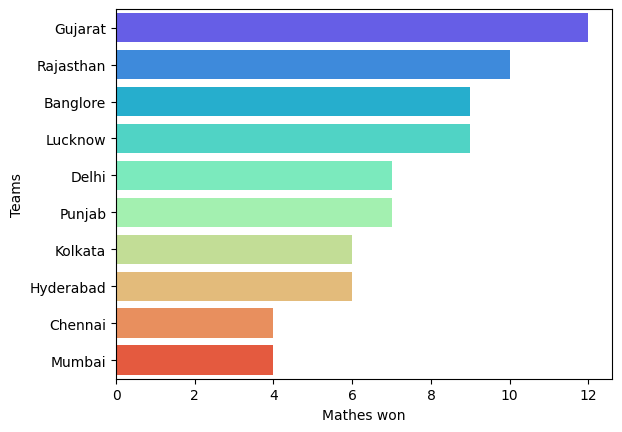

In [50]:
sns.barplot(y=match_wins.index, x=match_wins.values,hue=match_wins.index,palette="rainbow")
plt.xlabel("Mathes won")
plt.ylabel("Teams")

In [51]:
# toss decision treands mean if team wins toss what does they choose the most

df["toss_decision"].value_counts()

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

<Axes: xlabel='toss_decision', ylabel='count'>

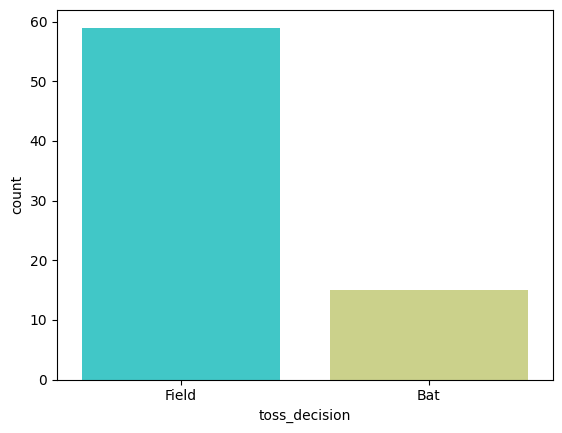

In [53]:
sns.countplot(x=df["toss_decision"],hue=df["toss_decision"],palette="rainbow")

In [65]:
# Toss winner vs match winner

count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
percentage = (count * 100) / df.shape[0]
percentage.round(2)

np.float64(48.65)

<Axes: xlabel='won_by', ylabel='count'>

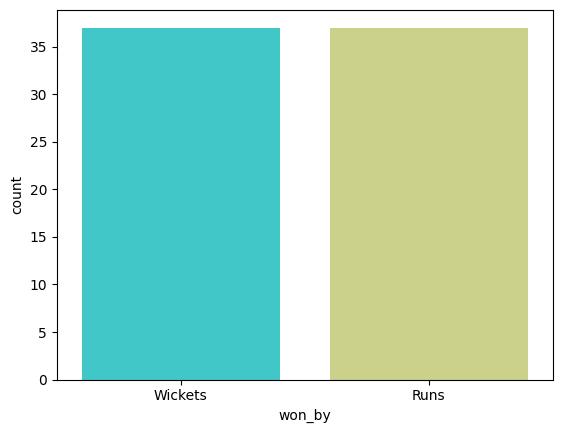

In [72]:
# How do teams win by runs or wickets?
df["won_by"].value_counts()
sns.countplot(x=df["won_by"],hue=df["won_by"],palette="rainbow")

#### KEY PLAYER PERFORMANCES

In [91]:
# most player of the match awards?
count = df["player_of_the_match"].value_counts().head(10)

<Axes: ylabel='player_of_the_match'>

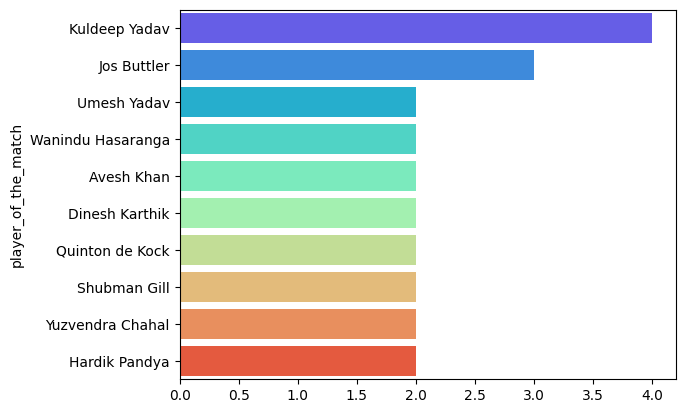

In [92]:
sns.barplot(y=count.index, x=count.values,hue=count.index,palette="rainbow")

In [101]:
# top 2 scorers
scorers = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)
scorers

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: xlabel='top_scorer'>

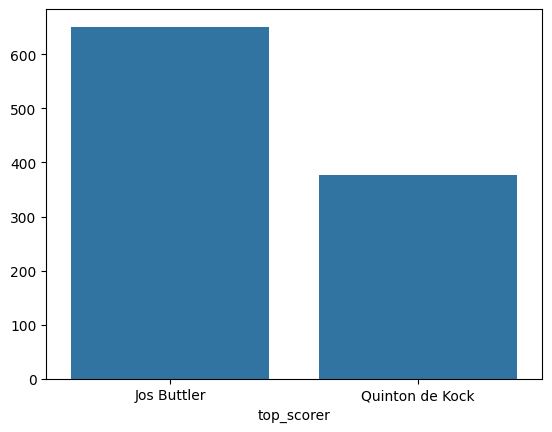

In [102]:
sns.barplot(x=scorers.index, y=scorers.values)

In [117]:
# ten best bowling figures

df["highest_wickets"] = df["best_bowling_figure"].apply(lambda x: x.split("--")[0])
df["highest_wickets"] = df["highest_wickets"].astype(int)
top_bowlers = df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending=False).head(10)
top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

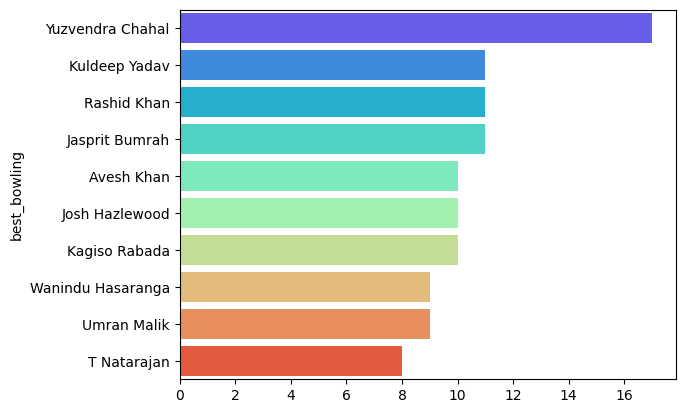

In [121]:
sns.barplot(x=top_bowlers.values, y=top_bowlers.index,hue=top_bowlers.index,palette="rainbow")

In [125]:
# most matches played by a venue
stadiums = df["venue"].value_counts()
stadiums

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

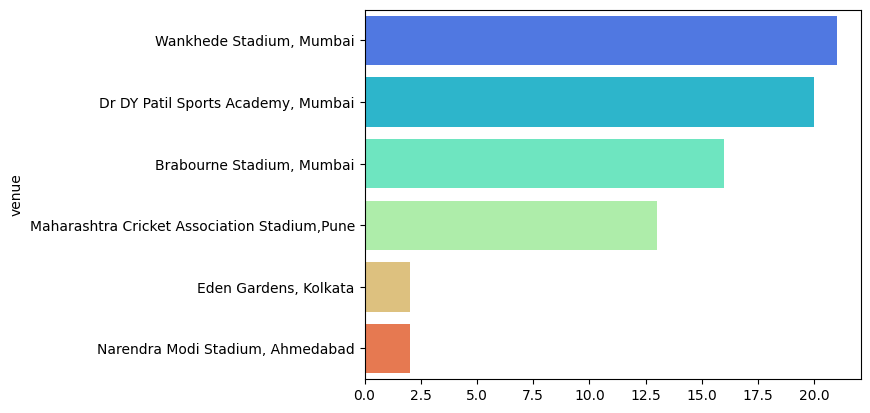

In [126]:
sns.barplot(y=stadiums.index,x=stadiums.values,hue=stadiums.index,palette="rainbow")

### CUSTON QUESTIONS AND INSIGHTS

In [148]:
# who won the highest margin by runs
# margin  won_by match_winner
# df.groupby("match_winner")["margin"].value_counts()

df[(df["won_by"] == "Runs")].sort_values(by="margin",ascending=False).head(1)[["match_winner","margin"]]



,match_winner,margin
54,Chennai,91


In [161]:
# which player has the highest indivisual score

# df.groupby("top_scorer")["highscore"].max().sort_values(ascending=False).head(1)

df[df["highscore"] == df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


In [168]:
# who has the best bowling figure?

# df[df["best_bowling_figure"] == df["best_bowling_figure"].max()][["best_bowling","best_bowling_figure"]]

df[df["highest_wickets"] == df["highest_wickets"].max()][["best_bowling","best_bowling_figure"]]


,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
